In [2]:
import pandas as pd 
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("C:/Users/sreev/OneDrive/Desktop/churn_analysis/Churn_Modelling.csv")

In [5]:
df = df.drop(['RowNumber' , 'CustomerId', 'Surname'],axis = 1)

In [6]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

In [7]:
x = df.drop('Exited' , axis = 1)
y = df['Exited']

In [13]:
## Train split test

In [15]:
x_train, x_test, y_train, y_test = train_test_split( x , y , test_size = 0.2, random_state = 42)

In [16]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [17]:
model = LogisticRegression()
model.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(x_test)

In [19]:
print("Accuracy:" , accuracy_score(y_test, y_pred))

Accuracy: 0.8155


In [20]:
confusion_matrix(y_test , y_pred)

array([[1559,   48],
       [ 321,   72]])

In [21]:
classification_report(y_test , y_pred)

'              precision    recall  f1-score   support\n\n           0       0.83      0.97      0.89      1607\n           1       0.60      0.18      0.28       393\n\n    accuracy                           0.82      2000\n   macro avg       0.71      0.58      0.59      2000\nweighted avg       0.78      0.82      0.77      2000\n'

In [22]:
model.coef_

array([[-0.0672648 ,  0.08943059, -0.26959964,  0.75472247, -0.04025947,
         0.30257658, -0.0270898 , -0.00324732, -0.53600774,  0.01914003]])

## Churn distribution

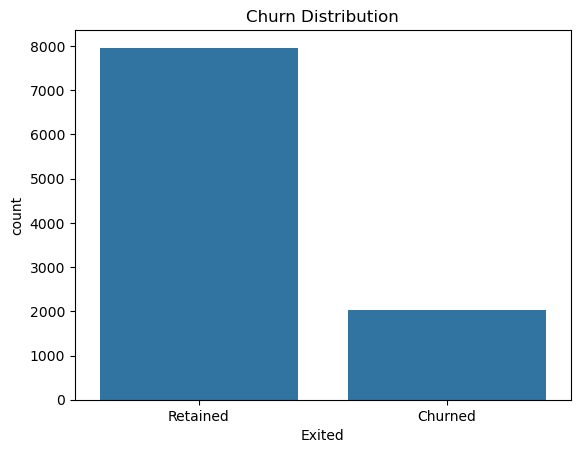

In [25]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.countplot(x = 'Exited' , data = df)
plt.title("Churn Distribution")
plt.xticks([0,1],['Retained', 'Churned'])
plt.show()

In [ ]:
# Insight:
# The dataset shows a clear class imbalance, with significantly fewer churned customers compared to retained ones.
# This indicates that churn prediction is a challenging problem and model evaluation should focus on recall for churned customers.

## Churn by Geography

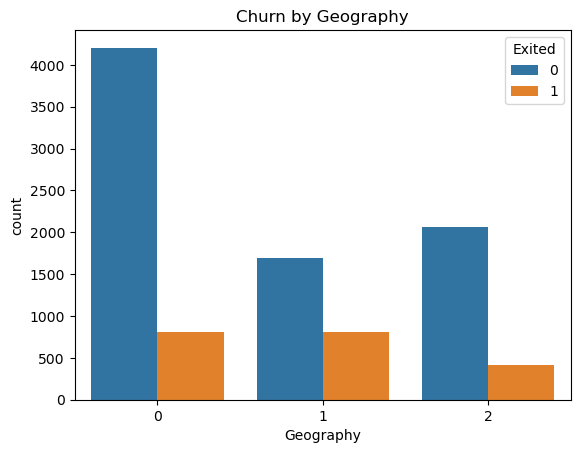

In [26]:
sns.countplot(x='Geography', hue = 'Exited', data = df)
plt.title("Churn by Geography")
plt.show()

In [ ]:
# Insight:
# Churn rates vary across regions, with certain geographies (e.g., Germany) showing higher churn.
# This suggests regional factors such as competition, service quality, or customer expectations may influence churn behavior.

## Churn by Gender

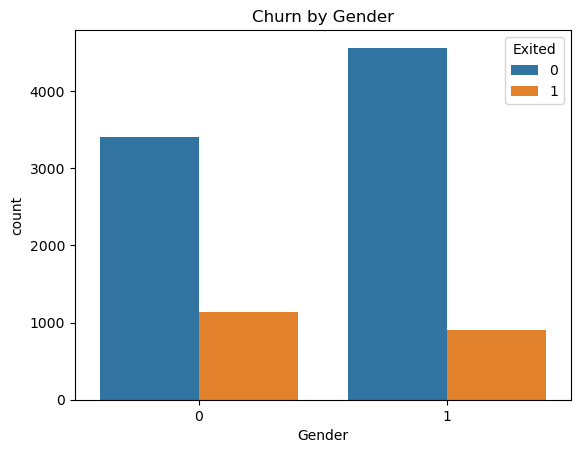

In [27]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Churn by Gender")
plt.show()

In [ ]:
# Insight:
# Churn distribution across gender is relatively balanced, indicating gender is not a strong standalone predictor of churn.
# However, it may still contribute when combined with other features.

## Active vs Inactive

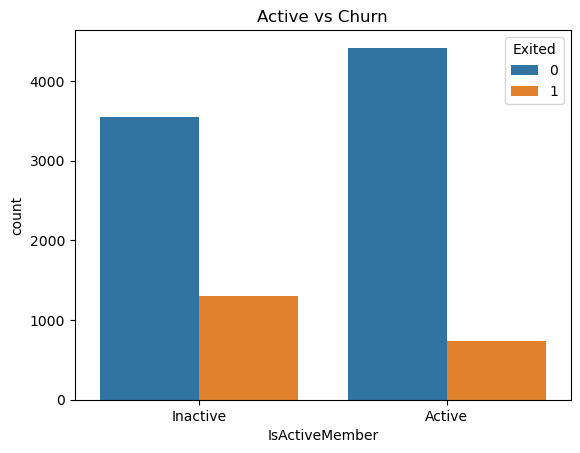

In [28]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title("Active vs Churn")
plt.xticks([0,1],['Inactive', 'Active'])
plt.show()

In [ ]:
# Insight:
# Inactive customers have a significantly higher churn rate compared to active customers.
# This highlights customer engagement as a critical factor in retention, suggesting targeted engagement strategies can reduce churn.

## Balance Distribution

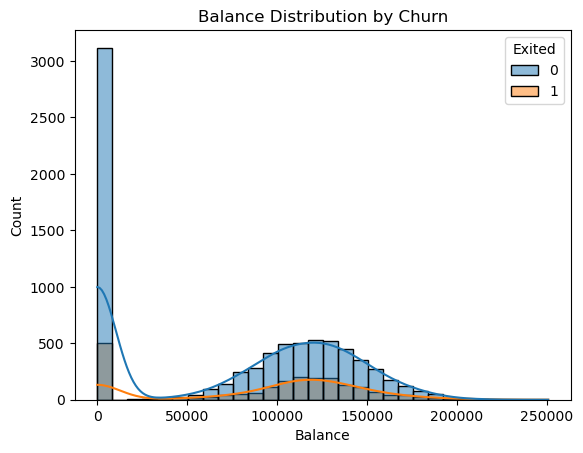

In [29]:
sns.histplot(data=df, x='Balance', hue='Exited', bins=30, kde=True)
plt.title("Balance Distribution by Churn")
plt.show()

In [ ]:
# Insight:
# Customers with higher balances show noticeable churn behavior, indicating that even high-value customers are at risk.
# This suggests the need for personalized retention strategies for high-balance clients.

## Age vs Churn

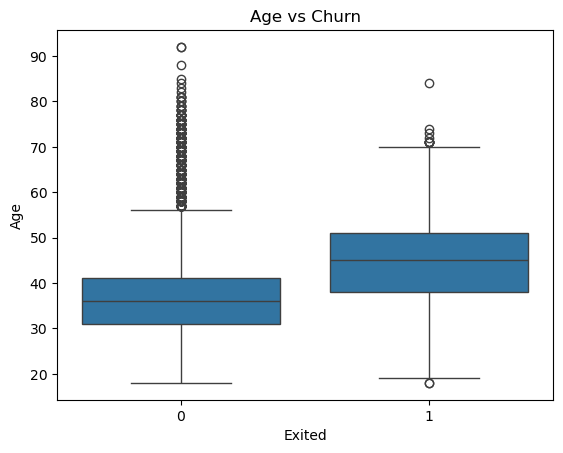

In [31]:
sns.boxplot(x='Exited', y='Age', data = df)
plt.title("Age vs Churn")
plt.show()

In [ ]:
# Insight:
# Customers in the middle-age group tend to churn more compared to younger and older customers.
# This may indicate that mid-career individuals are more likely to switch banks for better financial products or services.

## Credit Score vs Churn

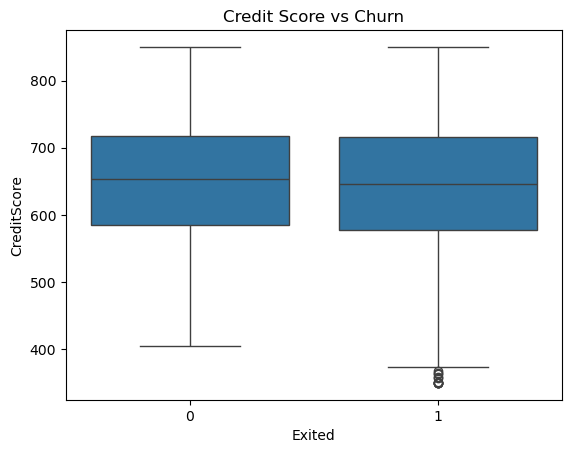

In [32]:
sns.boxplot(x='Exited', y='CreditScore' , data=df)
plt.title("Credit Score vs Churn")
plt.show()

In [ ]:
# Insight:
# Customers with lower credit scores tend to churn slightly more, although the difference is not very strong.
# Credit score alone may not be a key driver but can contribute when combined with other factors.

## Correlation Heatmap 

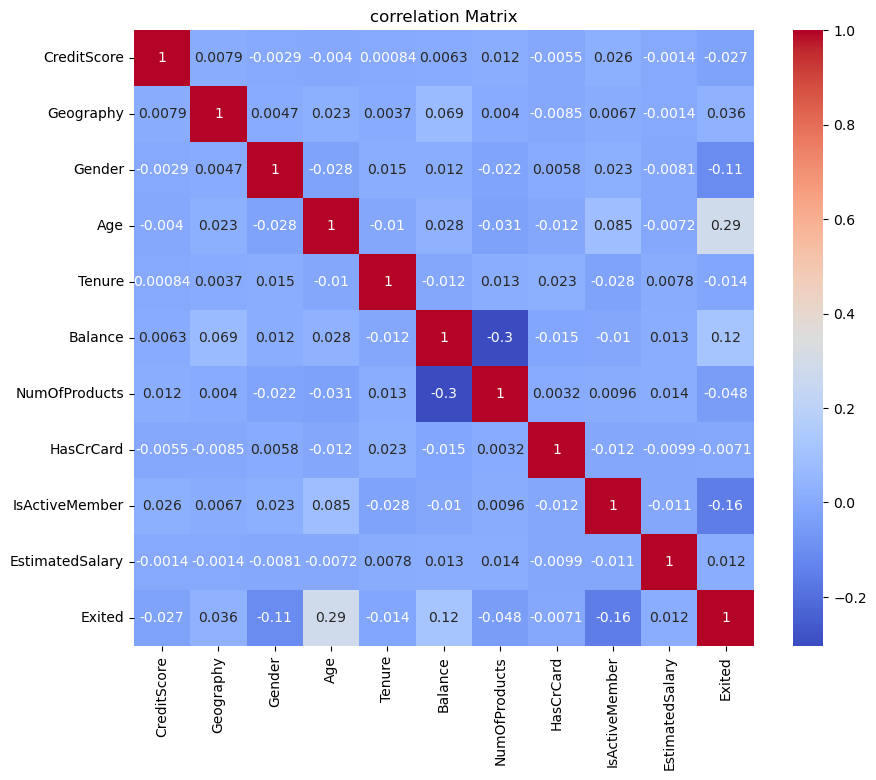

In [33]:
plt.figure(figsize = (10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("correlation Matrix")
plt.show()

In [ ]:
# Insight:
# Most features show low to moderate correlation with churn, indicating no single variable strongly explains churn behavior.
# This suggests that churn is driven by a combination of factors rather than a single dominant variable.

In [ ]:
# FINAL INSIGHTS

# 1. Inactive customers are the most likely to churn, making engagement a key factor.
# 2. Customers with fewer products (especially one) show higher churn behaviour.
# 3. Certain regions exhibit higher churn, indicating geographic influence.
# 4. Middle-aged customers are more prone to churn.
# 5. High-balance customers are also at risk, making retention of premium customers critical.